#  Cat vs. Dog Image Classification

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, AveragePooling2D

from keras.losses import binary_crossentropy
from keras.optimizers import Adam

In [22]:
import cv2

In [4]:
import kagglehub
import os

# Image Load

```python

keras.utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

```

In [5]:
# Download latest version
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print("Path to dataset files:", path)

# find images folder
print("Top-level folders:", os.listdir(path))

# adjust depending on what folder contains Cat/Dog
image_dir = os.path.join(path, "PetImages")

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset
Top-level folders: ['PetImages', 'readme[1].txt', 'MSR-LA - 3467.docx']


In [6]:
# Function to collect valid image paths and their labels
def get_filtered_image_data(image_directory):
    all_image_paths = []
    all_image_labels = []
    skipped_count = 0
    class_names_map = {"Cat": 0, "Dog": 1} # Mapping class names to integer labels

    for folder_name in ("Cat", "Dog"):
        folder_path = os.path.join(image_directory, folder_name)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} not found. Skipping.")
            continue
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                # Attempt to read and decode the image using TensorFlow functions
                # Use decode_image for more general handling (PNG, BMP, GIF, JPEG)
                img_bytes = tf.io.read_file(fpath)
                _ = tf.image.decode_image(img_bytes) # Just try decoding, don't store image yet
                all_image_paths.append(fpath)
                all_image_labels.append(class_names_map[folder_name])
            except (tf.errors.InvalidArgumentError, tf.errors.OutOfRangeError) as e:
                # Catch various decoding errors (e.g., 'Input is empty', wrong format)
                print(f"Skipping corrupt or undecodable image: {fpath} (Error: {e})")
                skipped_count += 1
            except Exception as e:
                # Catch any other unexpected file errors
                print(f"Skipping file due to unexpected error {e}: {fpath}")
                skipped_count += 1
    return all_image_paths, all_image_labels, skipped_count, list(class_names_map.keys())

print("Collecting and filtering dataset paths...")
all_paths, all_labels, skipped_count, detected_class_names = get_filtered_image_data(image_dir)
print(f"Skipped {skipped_count} corrupt or undecodable images.")

# Split the filtered data into training and testing sets
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=123, stratify=all_labels
)

# Preprocessing function for individual images
def preprocess_image(image_path, label, image_size=(256, 256), channels=3):
    img_bytes = tf.io.read_file(image_path)
    # Use decode_image to handle various image formats, ensure 3 channels
    img = tf.image.decode_image(img_bytes, channels=channels, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32) # Normalize to [0,1]
    img = tf.image.resize(img, image_size)
    return img, label

batch_size = 32
image_size = (256, 256)

# Create tf.data.Dataset for training
train_ds = tf.data.Dataset.from_tensor_slices((tf.constant(train_paths), tf.constant(train_labels)))
train_ds = train_ds.map(lambda x, y: preprocess_image(x, y, image_size), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Create tf.data.Dataset for testing
test_ds = tf.data.Dataset.from_tensor_slices((tf.constant(test_paths), tf.constant(test_labels)))
test_ds = test_ds.map(lambda x, y: preprocess_image(x, y, image_size), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# To satisfy subsequent cells that expect 'image_ds' and 'class_names'
# 'image_ds' can be a combined or just the training set for display purposes
image_ds = train_ds.concatenate(test_ds) # For general display/inspection
class_names = detected_class_names

# Calculate counts (note: cardinality can be UNKNOWN_CARDINALITY for dynamic datasets)
# Using length of paths for more direct sample counts.

print(f"Total valid images: {len(all_paths)}")
print(f"Training samples: {len(train_paths)}")
print(f"Test samples: {len(test_paths)}")
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy()) # May show -2 if unknown
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy()) # May show -2 if unknown
print("Class names:", class_names)

Skipping corrupt or undecodable image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/4351.jpg (Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: )
Skipping corrupt or undecodable image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/Thumbs.db (Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: )
Skipping corrupt or undecodable image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg (Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input is empty. [Op:DecodeImage] name: )
Skipping corrupt or undecodable image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/10404.jpg (Error: {{function_node __wrapped__Dec

## Show a batch

In [7]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels:", labels.numpy()[:10])

Images shape: (32, 256, 256, 3)
Labels: [1 1 0 0 0 1 0 1 0 1]


## Visualize 9 sample images

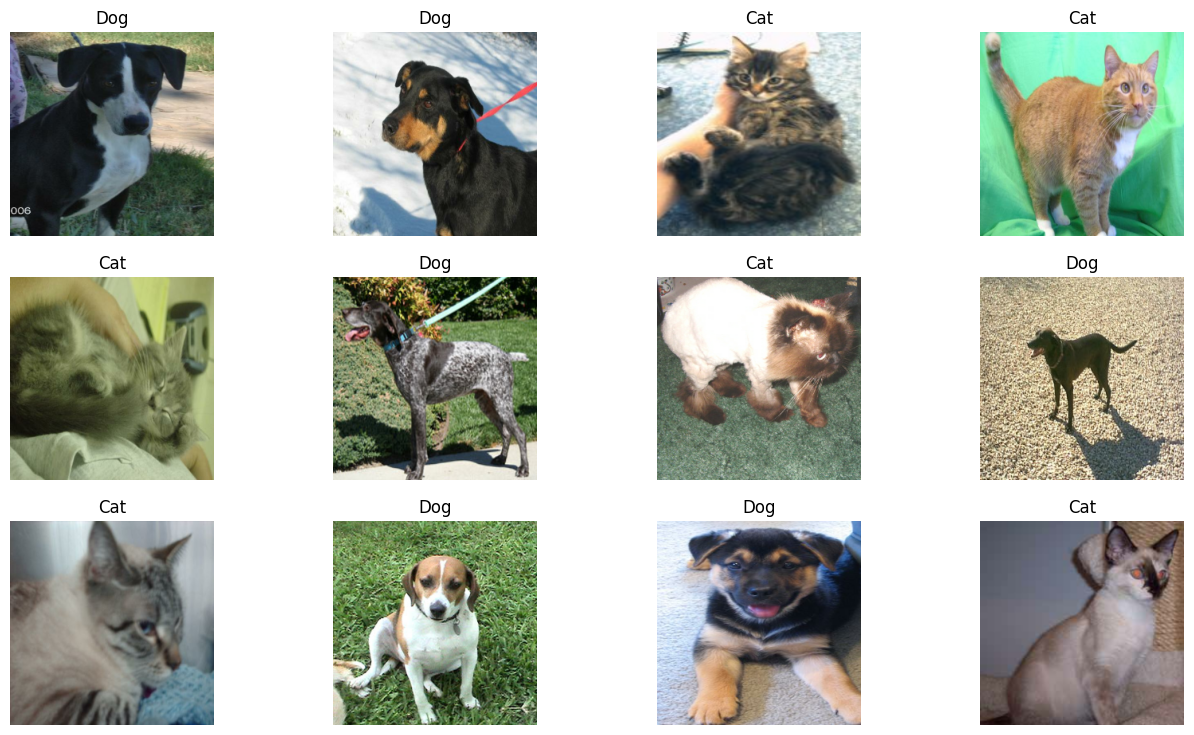

In [8]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(16, 9))
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
    break


## Verify sample counts

In [9]:
print(len(all_paths))       # total valid images
print(len(train_paths))     # training samples
print(len(test_paths))      # test samples


24991
19992
4999


## Confirm dataset cardinality

In [10]:
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())


Train batches: 625
Test batches: 157


# Normalize Image

In [11]:
train_ds = train_ds.map(lambda x, y: (x / 255, y))
test_ds = test_ds.map(lambda x, y: (x / 255, y))

# Custom Model - `LeNET-5`

In [16]:
def lenet5() -> Sequential:
  model = Sequential()

  # Input Layer
  model.add(Input(shape=(256, 256, 3)))

  # Convolution Layer 1
  model.add(Conv2D(filters=6, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='same'))
  model.add(AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

  # Convolution Layer 2
  model.add(Conv2D(filters=16, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'))
  model.add(AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

  # Flatten Layer
  model.add(Flatten())

  # Full connected layer
  model.add(Dense(units=120, activation='tanh'))
  model.add(Dense(units=84, activation='tanh'))
  model.add(Dense(units=2, activation='softmax'))

  return model

In [17]:
model = lenet5()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 128, 128, 6)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 124, 124, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 62, 62, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 61504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │     7,380,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,806 (28.21 MB)

 Trainable params: 7,393,806 (28.21 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [18]:
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    train_ds,
    epochs=15,
    validation_data=test_ds,
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 72ms/step - accuracy: 0.4952 - loss: 0.7580 - val_accuracy: 0.5001 - val_loss: 0.6931
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.4918 - loss: 0.7148 - val_accuracy: 0.4999 - val_loss: 0.6934
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.4944 - loss: 0.7145 - val_accuracy: 0.4999 - val_loss: 0.6935
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.4949 - loss: 0.7148 - val_accuracy: 0.4999 - val_loss: 0.6932
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.4951 - loss: 0.7144 - val_accuracy: 0.4999 - val_loss: 0.6933
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.4947 - loss: 0.7145 - val_accuracy: 0.4999 - val_loss: 0.6933
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.4953 - loss: 0.7143 - val_accuracy: 0.4999 - val_loss: 0.6933
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.4953 - loss: 0.7144 - 

# Accuracy Plot

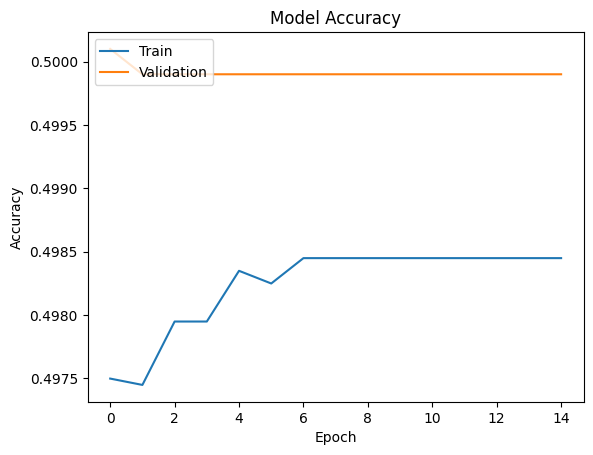

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Loss Plot

<function matplotlib.pyplot.show(close=None, block=None)>

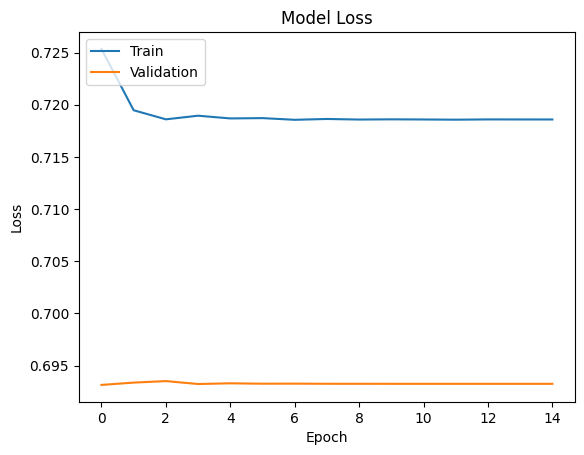

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show

# Test `Cat` Image

## Image Load

In [41]:
cat_image = cv2.imread('cat_image.jpg')
cat_image = cv2.resize(cat_image, (256, 256))
cat_image = cat_image / 255.0

## Visualize Image

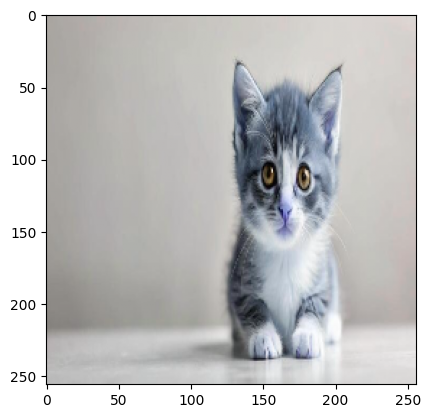

In [42]:
plt.imshow(cat_image)

## Reshape Image `Batch-Size`

In [39]:
cat_image.shape

(256, 256, 3)

In [43]:
cat_image = np.expand_dims(cat_image, axis=0)
cat_image.shape

(1, 256, 256, 3)

In [45]:
model.predict(cat_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


array([[0.4929337, 0.5070663]], dtype=float32)

# Test Dog Image

## Image Data Load

In [46]:
dog_image = cv2.imread('dog_image.jpg')
dog_image = cv2.resize(dog_image, (256, 256))
dog_image = dog_image / 255.0

## Visualize Image

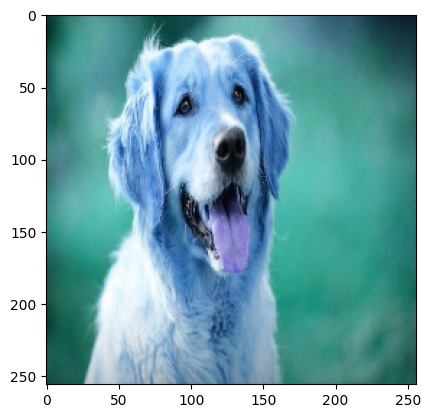

In [47]:
plt.imshow(dog_image)

## Reshape

In [48]:
dog_image.shape

(256, 256, 3)

In [49]:
dog_image = np.expand_dims(dog_image, axis=0)
dog_image.shape

(1, 256, 256, 3)

## Predict

In [50]:
model.predict(dog_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[0.4929147 , 0.50708526]], dtype=float32)